# ***ANÁLISIS EXPLORATORIO DE DATOS (EDA)***

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
import seaborn as sns

In [27]:
df = pd.read_csv('../data/diabetes_preprocesado.csv', sep=",", quotechar='"')

C:\Users\elena\AppData\Local\Temp\ipykernel_23572\1069022805.py:1: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/diabetes_preprocesado.csv', sep=",", quotechar='"')


## 1- Estadística Descriptiva

In [28]:
df.describe()

,encounter_id,patient_nbr,race,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,num_lab_procedures,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
count,9.805300e+04,9.805300e+04,98053.000000,98053.000000,98053.000000,98053.000000,98053.000000,9.805300e+04,98053.000000,98053.000000,...,98053.0,98053.000000,98053.000000,98053.000000,98053.000000,98053.0,98053.000000,98053.000000,98053.000000,98053.000000
mean,1.658294e+08,5.484792e+07,0.624052,6.126034,2.025813,3.753368,5.776692,-1.507276e-17,0.279088,-0.032766,...,0.0,1.053267,0.013676,0.000265,0.000020,0.0,0.000020,0.461781,0.768472,0.579085
std,1.024322e+08,3.866175e+07,0.258139,1.559075,1.450117,5.309392,4.071640,1.000005e+00,0.213726,0.758155,...,0.0,1.099934,0.165284,0.023027,0.006387,0.0,0.006387,0.498540,0.421811,0.685175
min,1.252200e+04,1.350000e+02,0.006374,0.000000,1.000000,1.000000,1.000000,-1.600220e+00,0.000010,-1.653846,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,8.528566e+07,2.350234e+07,0.765698,5.000000,1.000000,1.000000,1.000000,-8.411831e-01,0.072818,-0.500000,...,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000
50%,1.533019e+08,4.687790e+07,0.765698,6.000000,1.000000,1.000000,7.000000,1.150903e-01,0.142443,0.000000,...,0.0,1.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,1.000000,0.000000
75%,2.305007e+08,8.800306e+07,0.765698,7.000000,3.000000,4.000000,7.000000,7.449715e-01,0.492774,0.500000,...,0.0,2.000000,0.000000,0.000000,0.000000,0.0,0.000000,1.000000,1.000000,1.000000
max,4.438672e+08,1.895026e+08,0.765698,9.000000,8.000000,28.000000,25.000000,2.171709e+00,0.492774,3.384615,...,0.0,3.000000,3.000000,2.000000,2.000000,0.0,2.000000,1.000000,1.000000,2.000000


## 2- Distribuciones Univariadas

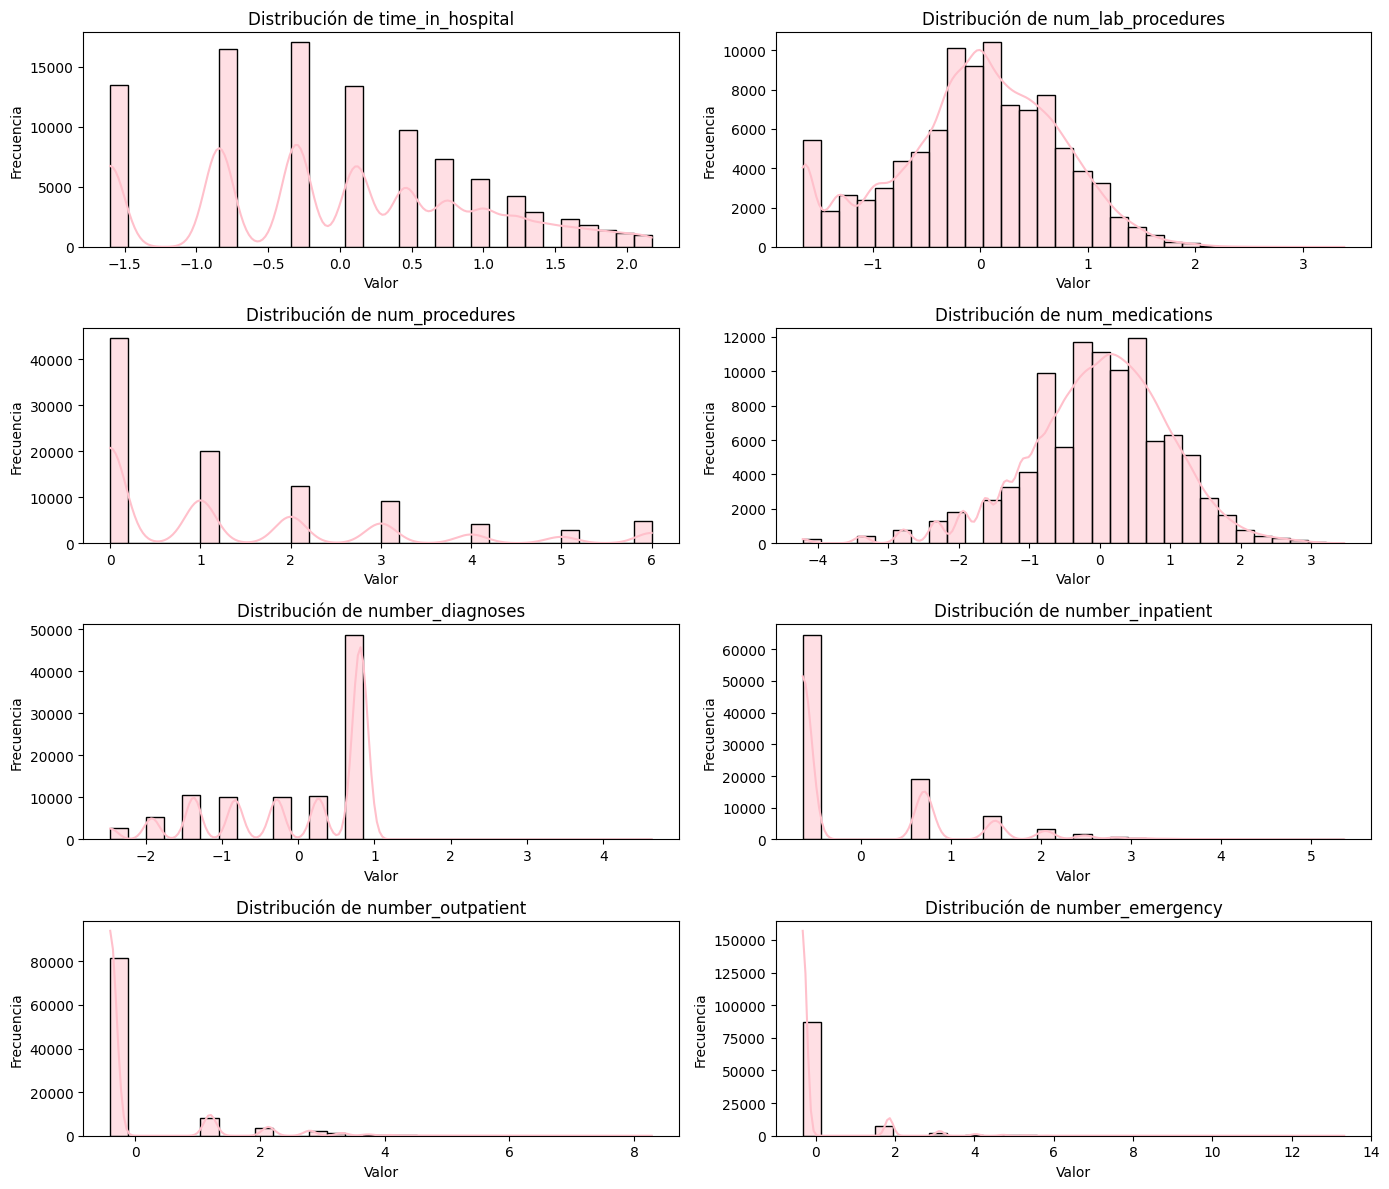

In [29]:
cols_analisis = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_diagnoses', 'number_inpatient', 
    'number_outpatient', 'number_emergency'
]

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, feature in enumerate(cols_analisis):
    sns.histplot(data=df, x=feature, kde=True, bins=30, ax=axes[idx], color='pink')
    axes[idx].set_title(f'Distribución de {feature}', fontsize=12)
    axes[idx].set_xlabel('Valor', fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.tight_layout()
plt.savefig("../visualizacion_eda/distr_univariada.png", bbox_inches='tight', dpi=100)
plt.show()  

## 3- Box Plots

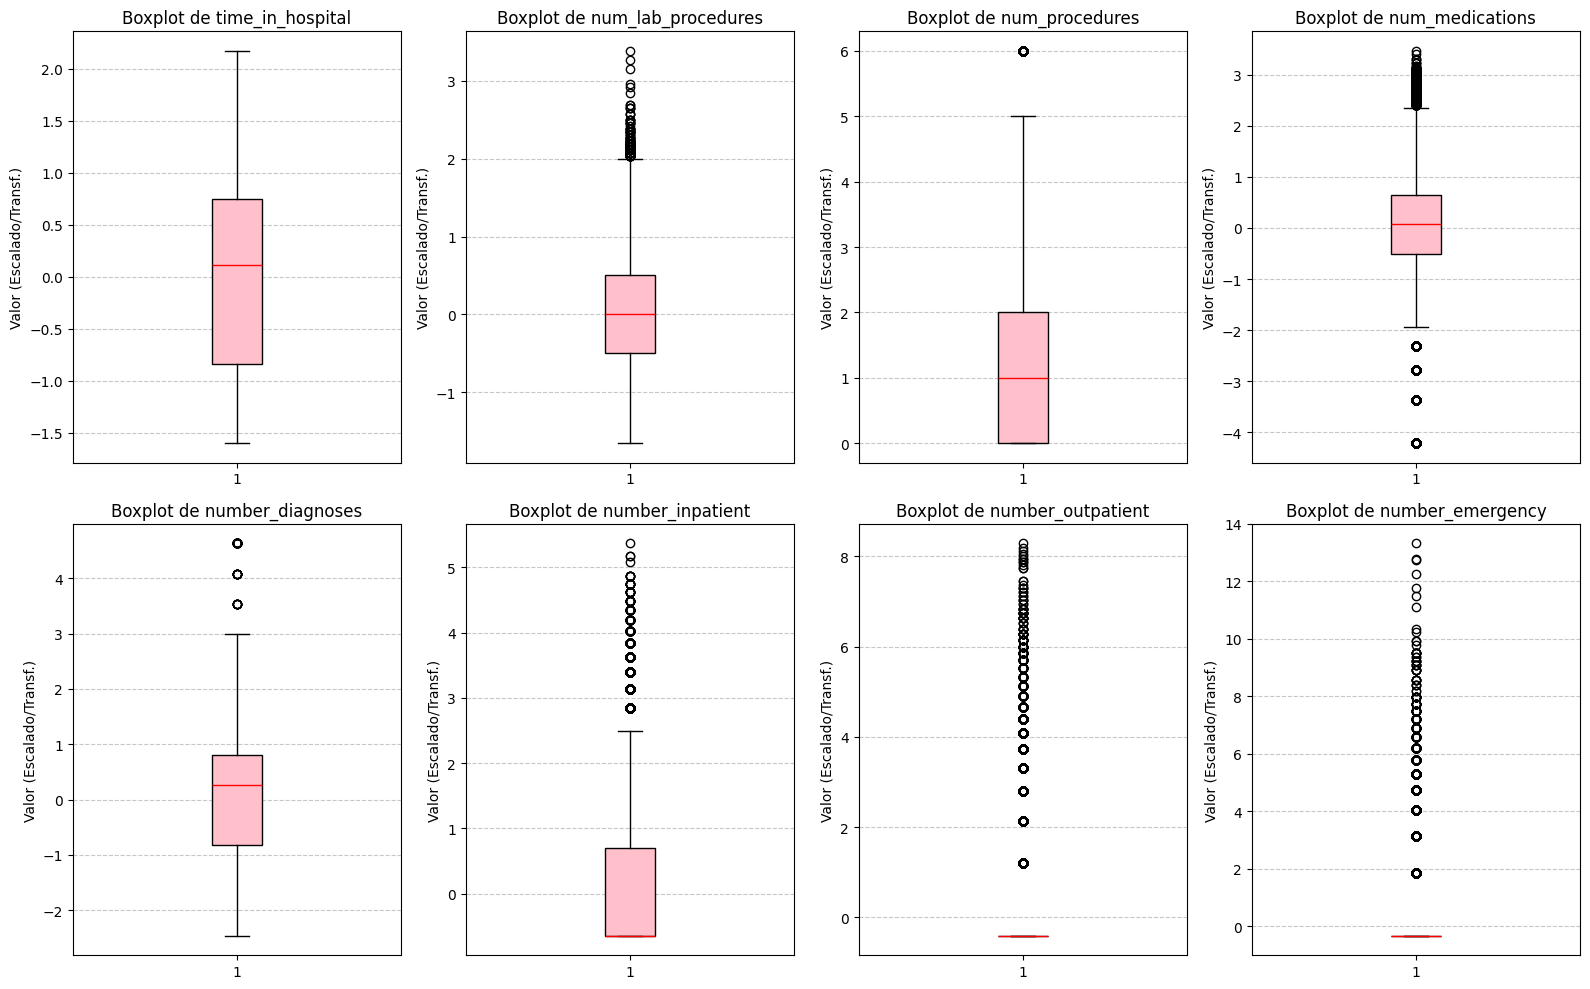

In [30]:
fig, axes = plt.subplots(2, 4, figsize=(16, 10))
axes = axes.flatten() # Aplanamos para iterar fácilmente

for idx, feature in enumerate(cols_analisis):
    # Dibujamos el boxplot. Usamos patch_artist para poder darle color.
    axes[idx].boxplot(df[feature], patch_artist=True, 
                      boxprops=dict(facecolor='pink', color='black'),
                      medianprops=dict(color='red'))
    
    axes[idx].set_title(f'Boxplot de {feature}', fontsize=12)
    axes[idx].set_ylabel('Valor (Escalado/Transf.)')
    axes[idx].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Ajuste de márgenes para que no se pisen los títulos
plt.tight_layout()
plt.savefig('../visualizacion_eda/boxplots_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

## 4- Relaciones Bivariadas

                    time_in_hospital  num_lab_procedures  num_procedures  \
time_in_hospital            1.000000            0.334147        0.164590   
num_lab_procedures          0.334147            1.000000        0.058665   
num_procedures              0.164590            0.058665        1.000000   
num_medications             0.460992            0.260568        0.336006   
number_diagnoses            0.227099            0.150289        0.058929   
number_inpatient            0.088377            0.043021       -0.077643   
number_outpatient          -0.013881           -0.021914       -0.035774   
number_emergency           -0.005997            0.002425       -0.052387   
age                         0.108519            0.016600       -0.042685   
readmitted                  0.064597            0.036404       -0.039178   

                    num_medications  number_diagnoses  number_inpatient  \
time_in_hospital           0.460992          0.227099          0.088377   
num_lab_proce

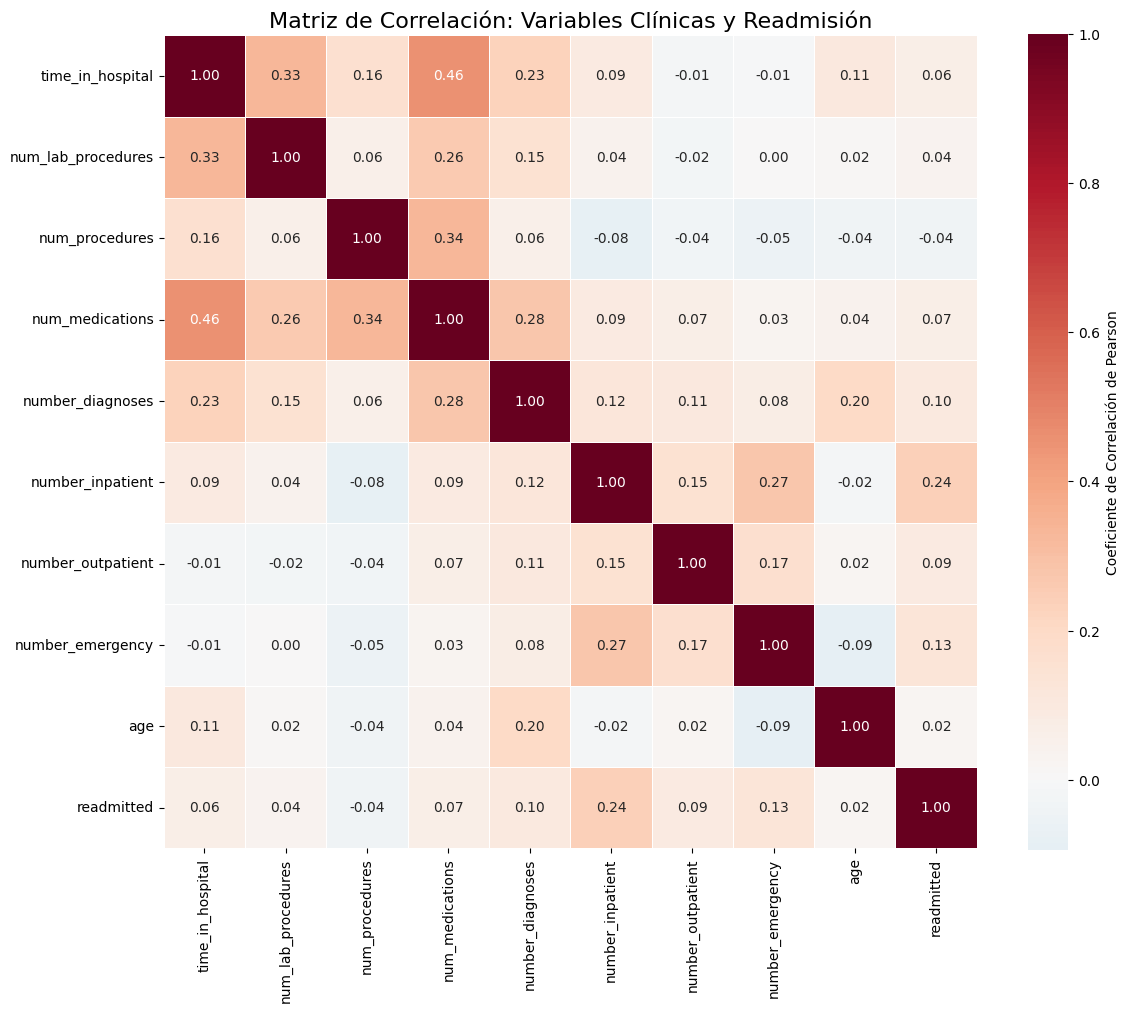

In [ ]:
cols_analisis = [
    'time_in_hospital', 'num_lab_procedures', 'num_procedures', 
    'num_medications', 'number_diagnoses', 'number_inpatient', 
    'number_outpatient', 'number_emergency', 'age', 'readmitted'
]

# 2. Calculamos la matriz solo para esas columnas
corr_matrix = df[cols_analisis].corr()
print(corr_matrix)

# 3. Visualización optimizada
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    annot=True,          # Muestra los números
    fmt='.2f',           # Dos decimales
    cmap='RdBu_r',       # Rojo (positivo) a Azul (negativo), muy claro para correlaciones
    center=0,            # El blanco es el 0 (sin correlación)
    square=True, 
    linewidths=.5,       # Separa un poco los cuadros
    ax=ax, 
    cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
)

ax.set_title('Matriz de Correlación: Variables Clínicas y Readmisión', fontsize=16)

# 4. Guardado y cierre
plt.tight_layout()
plt.savefig('../visualizacion_eda/correlacion_matrix_diabetes.png', dpi=300, bbox_inches='tight')
plt.show()

## 5- Scatter Plots

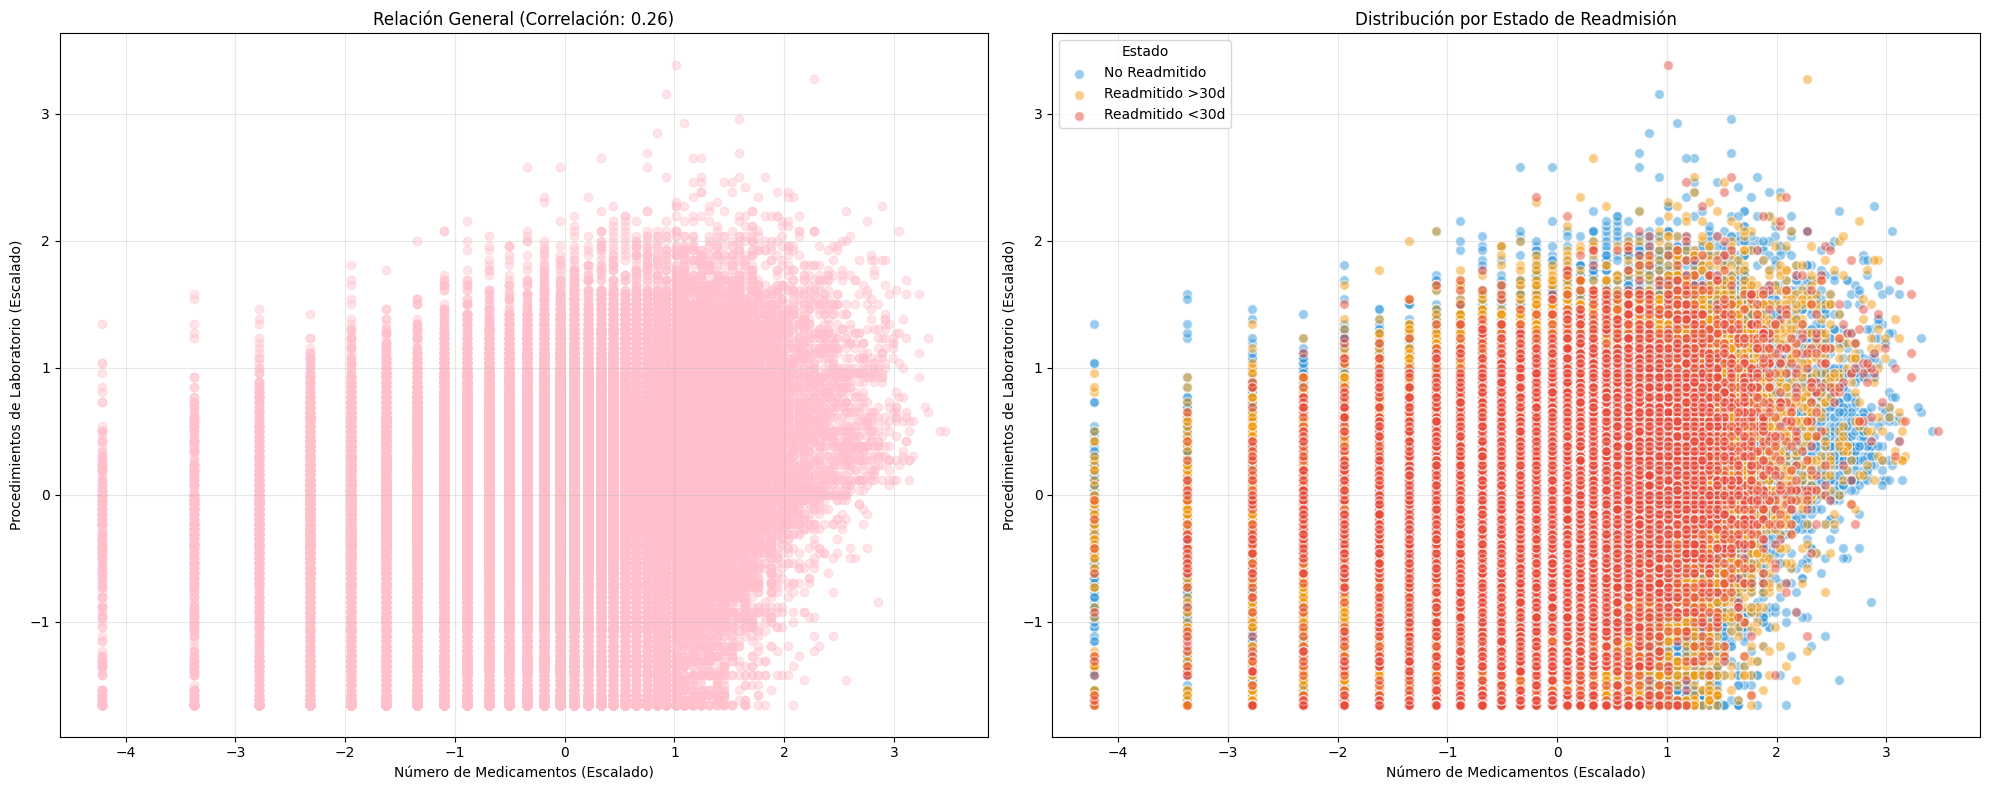

In [40]:
# 1. Definimos las variables a comparar
# 'num_medications' y 'num_lab_procedures':  relación interesante
x_feature = 'num_medications'
y_feature = 'num_lab_procedures'

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# --- GRÁFICO 1: Scatter Simple ---
correlacion = df[x_feature].corr(df[y_feature])

axes[0].scatter(df[x_feature], df[y_feature], alpha=0.4, color='pink')
axes[0].set_xlabel('Número de Medicamentos (Escalado)')
axes[0].set_ylabel('Procedimientos de Laboratorio (Escalado)')
axes[0].set_title(f'Relación General (Correlación: {correlacion:.2f})')
axes[0].grid(True, alpha=0.3)

# --- GRÁFICO 2: Scatter coloreado por Readmisión ---
# Mapeo inverso para que la leyenda sea legible (0=No, 1=>30, 2=<30)
labels_readmitted = {0: 'No Readmitido', 1: 'Readmitido >30d', 2: 'Readmitido <30d'}
colores_readmision = {0: '#3498db', 1: '#f39c12', 2: '#e74c3c'}

for valor, etiqueta in labels_readmitted.items():
    mask = df['readmitted'] == valor
    axes[1].scatter(df.loc[mask, x_feature], 
                    df.loc[mask, y_feature], 
                    label=etiqueta, 
                    color=colores_readmision[valor],
                    edgecolor='white',
                    alpha=0.5,
                    s=50)

axes[1].set_xlabel('Número de Medicamentos (Escalado)')
axes[1].set_ylabel('Procedimientos de Laboratorio (Escalado)')
axes[1].set_title('Distribución por Estado de Readmisión')
axes[1].legend(title="Estado")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../visualizacion_eda/scatter_plots_diabetes.png', dpi=300, bbox_inches='tight')
plt.show()